# Knee Osteoarthritis Classification using ResNet-50
## Configuration 2 with Balanced Dataset

This notebook sets up a ResNet-50 transfer learning experiment for knee osteoarthritis grading. It uses the balanced training split, standard image preprocessing, and a regularized classification head so we can compare ResNet-50 against the EfficientNet experiments.

### Workflow Overview
- **Data**: Uses the balanced training split (`train_balanced`) to avoid class bias
- **Preprocessing**: Baseline RGB preprocessing for a clean ResNet comparison
- **Architecture**: Pretrained ResNet-50 backbone with a regularized classification head
- **Training**: Two-phase fine-tuning with callbacks and class weights
- **Evaluation**: Accuracy, balanced accuracy, classification report, confusion matrix, and saved metrics

In [1]:
import sys
print(sys.executable)

/workspaces/fyp_experiment/.venv-4/bin/python


In [2]:
import os
import json
import timeit
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

I0000 00:00:1783494599.773847   59270 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as exc:
            print(f'Could not enable memory growth for {gpu}: {exc}')
    mixed_precision.set_global_policy('mixed_float16')

print('TF version:', tf.__version__)
print('GPUs:', gpus)
print('Mixed precision:', mixed_precision.global_policy())

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5050, compute capability 12.0
TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <Policy "mixed_float16">


W0000 00:00:1780233775.970674    8201 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Dataset Configuration

The notebook is wired to the balanced KOA dataset split used throughout the project.

In [4]:
def find_dataset_dir() -> Path:
    candidates = [
        Path('/workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis'),
        Path.cwd() / 'data' / 'knee_osteoarthritis',
        Path.cwd().resolve().parents[1] / 'data' / 'knee_osteoarthritis',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')

BASE_DIR = find_dataset_dir()
TRAIN_PATH = str(BASE_DIR / 'train_balanced')
VALID_PATH = str(BASE_DIR / 'val')
TEST_PATH = str(BASE_DIR / 'test')
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = len(CLASS_NAMES)
SEED = 12049

print('BASE_DIR:', BASE_DIR)
print('TRAIN_PATH:', TRAIN_PATH)
print('VALID_PATH:', VALID_PATH)
print('TEST_PATH:', TEST_PATH)
print('CLASS_NAMES:', CLASS_NAMES)

BASE_DIR: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis
TRAIN_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/train_balanced
VALID_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/val
TEST_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/test
CLASS_NAMES: ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']


## 2. Helpers

These helpers inspect the dataset and compute the evaluation outputs used later in the notebook.

In [5]:
def get_classes(data_path, classes, data):
    print(f'----{data}----')
    knee_severity = {}
    count = 0
    for i in range(len(classes)):
        imgs = os.listdir(os.path.join(data_path, str(i)))
        knee_severity[i] = imgs
        count += len(imgs)
    for k, v in knee_severity.items():
        print(f'Grade {k}-{classes[k]}: {len(v)} images, {round((len(v) * 100) / count, 2)}%')
    return knee_severity

def plot_classes(dict_classes, data_path, classes, data):
    for k, v in dict_classes.items():
        print(f'{data}-{classes[k]}')
        plt.figure(figsize=(10, 25))
        for i in range(5):
            img_path = os.path.join(data_path, str(k), v[i])
            img = tf.keras.preprocessing.image.load_img(img_path)
            plt.subplot(1, 5, 1 + i, xticks=[], yticks=[])
            plt.imshow(img)
            plt.title(f'Grade {k}')
        plt.show()

def compute_confusion_matrix(ytrue, ypred, class_names, model_name):
    pred_values = np.asarray(ypred).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    pred_labels = np.rint(pred_values).astype(int)
    cm = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    cmn = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f'Accuracy Score - {model_name}: {acc:.2f}')
    print(f'Balanced Accuracy Score - {model_name}: {bal_acc:.2f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [6]:
def get_plot_loss_acc(history_obj, model_name):
    history_data = history_obj.history if hasattr(history_obj, 'history') else history_obj
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(history_data['loss'])
    plt.plot(history_data['val_loss'])
    plt.title(f'{model_name} - Loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'valid'], loc='upper right')

    plt.subplot(2, 1, 2)
    plt.plot(history_data['accuracy'])
    plt.plot(history_data['val_accuracy'])
    plt.title(f'{model_name} - Accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'valid'], loc='lower right')
    plt.tight_layout()

@tf.keras.utils.register_keras_serializable(package='koa')
class OrdinalAccuracy(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='ordinal_accuracy', **kwargs):
        super(OrdinalAccuracy, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.counter = self.add_weight(name='counter', initializer='zeros', dtype=tf.float32)
        self.correct = self.add_weight(name='correct', initializer='zeros', dtype=tf.float32)
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        y_pred = tf.clip_by_value(tf.round(y_pred), 0.0, float(self.num_classes - 1))
        matches = tf.cast(tf.equal(y_true, y_pred), tf.float32)
        self.correct.assign_add(tf.reduce_sum(matches))
        self.counter.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))
    
    def result(self):
        return self.correct / (self.counter + tf.keras.backend.epsilon())
    
    def reset_state(self):
        self.counter.assign(0.0)
        self.correct.assign(0.0)
    
    def get_config(self):
        config = super().get_config()
        config.update({'num_classes': self.num_classes})
        return config

def ordinal_predictions_to_labels(predictions, class_names):
    pred_values = np.asarray(predictions).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    pred_labels = np.rint(pred_values).astype(int)
    return pred_values, pred_labels
def ordinal_score_matrix(predictions, class_names):
    pred_values = np.asarray(predictions).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    class_positions = np.arange(len(class_names), dtype=np.float32)
    scores = 1.0 / (1.0 + np.abs(pred_values[:, None] - class_positions[None, :]))
    scores = scores / np.sum(scores, axis=1, keepdims=True)
    return scores

def compute_confusion_matrix(ytrue, ypred, class_names, model_name):
    _, pred_labels = ordinal_predictions_to_labels(ypred, class_names)
    cmatrix = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    cmn = cmatrix.astype(float) / cmatrix.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def compute_confusion_matrix_counts(ytrue, ypred, class_names, model_name):
    _, pred_labels = ordinal_predictions_to_labels(ypred, class_names)
    cmatrix = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmatrix, annot=True, fmt='d', cmap='YlOrRd', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def get_evaluate(data, name, model):
    score_model = model.evaluate(data, verbose=1, return_dict=True)
    print(f'{name} loss: {score_model["loss"]:.2f}')
    if 'mae' in score_model:
        print(f'{name} mae: {score_model["mae"]:.2f}')
    if 'accuracy' in score_model:
        print(f'{name} accuracy: {score_model["accuracy"]:.2f}')

def get_predict(data, model):
    return model.predict(data)

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f'Accuracy Score - {model_name}: {acc:.2f}')
    print(f'Balanced Accuracy Score - {model_name}: {bal_acc:.2f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

def compute_comprehensive_metrics(y_true, y_pred_probs, y_pred_labels, class_names, model_name):
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import mean_absolute_error

    print('=' * 80)
    print(f'COMPREHENSIVE EVALUATION - {model_name}')
    print('=' * 80)

    acc = accuracy_score(y_true, y_pred_labels)
    bal_acc = balanced_accuracy_score(y_true, y_pred_labels)
    mae = mean_absolute_error(y_true, np.asarray(y_pred_probs).reshape(-1))
    print(f'\nOVERALL ACCURACY:')
    print(f'   Accuracy: {acc:.4f}')
    print(f'   Balanced Accuracy: {bal_acc:.4f}')
    print(f'   MAE: {mae:.4f}')
    print(f'\nDETAILED CLASSIFICATION REPORT:')
    print(classification_report(y_true, y_pred_labels, target_names=class_names, digits=4))

    try:
        y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
        roc_scores = ordinal_score_matrix(y_pred_probs, class_names)
        roc_auc_macro = roc_auc_score(y_true_bin, roc_scores, multi_class='ovr', average='macro')
        roc_auc_weighted = roc_auc_score(y_true_bin, roc_scores, multi_class='ovr', average='weighted')
        print(f'\nROC AUC SCORES:')
        print(f'   ROC AUC (Macro): {roc_auc_macro:.4f}')
        print(f'   ROC AUC (Weighted): {roc_auc_weighted:.4f}')
    except Exception as exc:
        print(f'\nROC AUC calculation note: {str(exc)}')

def plot_roc_curves(y_true, y_pred_probs, class_names, model_name):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc

    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    score_matrix = ordinal_score_matrix(y_pred_probs, class_names)
    plt.figure(figsize=(12, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], score_matrix[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_f1_scores_per_class(y_true, y_pred_labels, class_names, model_name):
    from sklearn.metrics import f1_score

    f1_scores = []
    for i in range(len(class_names)):
        f1 = f1_score(y_true, y_pred_labels, labels=[i], average='weighted', zero_division=0)
        f1_scores.append(f1)

    colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
    for bar, score in zip(bars, f1_scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2., height, f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
    plt.xlabel('Osteoarthritis Grade', fontsize=12, fontweight='bold')
    plt.title(f'F1 Score Distribution - {model_name}', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.1])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Data Loading

ResNet-50 will use RGB inputs and native ImageNet preprocessing.

In [8]:
train_data = get_classes(TRAIN_PATH, CLASS_NAMES, 'train_balanced')
valid_data = get_classes(VALID_PATH, CLASS_NAMES, 'Valid')
test_data = get_classes(TEST_PATH, CLASS_NAMES, 'Test')

datagen = tf.keras.preprocessing.image.ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)
train_generator = datagen.flow_from_directory(TRAIN_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=True)
valid_generator = datagen.flow_from_directory(VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)

print('Using sparse integer labels for ordinal regression.')

----train_balanced----
Grade 0-Healthy: 2246 images, 20.01%
Grade 1-Doubtful: 2245 images, 20.0%
Grade 2-Minimal: 2245 images, 20.0%
Grade 3-Moderate: 2245 images, 20.0%
Grade 4-Severe: 2245 images, 20.0%
----Valid----
Grade 0-Healthy: 328 images, 39.71%
Grade 1-Doubtful: 153 images, 18.52%
Grade 2-Minimal: 212 images, 25.67%
Grade 3-Moderate: 106 images, 12.83%
Grade 4-Severe: 27 images, 3.27%
----Test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%
Found 11226 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Using sparse integer labels for ordinal regression.


## 4. Model Configuration

### Training Parameters
Define all hyperparameters and paths for the ResNet50 model. These settings have been optimized for balanced accuracy across all osteoarthritis severity grades.

In [ ]:
model_dir = Path('models')
model_dir.mkdir(exist_ok=True)
save_model_ft = str(model_dir / 'best_model.keras')

model_name = 'ResNet50_c2'
phase1_epochs = 20
phase2_epochs = 30
fine_tune_layers = 30
weight_decay = 2e-4

checkpoint = ModelCheckpoint(
    save_model_ft, monitor='val_loss', save_best_only=True, mode='min', verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
csv_logger_phase1 = CSVLogger('train_history.csv', append=False)

## 5. Training Setup

Use this cell to add callbacks, compile the model, and run the frozen-backbone warmup followed by fine-tuning.

In [9]:
model_dir = Path('models')
model_dir.mkdir(exist_ok=True)
save_model_ft = str(model_dir / 'best_model.keras')
print('Model will be saved to:', save_model_ft)

Model will be saved to: models/best_model.keras


In [9]:
def build_generators(train_path, valid_path, test_path, img_size, batch_size):
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
        rotation_range=5,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest',
    )
    eval_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    )

    train_generator = train_datagen.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=True,
    )
    valid_generator = eval_datagen.flow_from_directory(
        valid_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=False,
    )
    test_generator = eval_datagen.flow_from_directory(
        test_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=False,
    )

    return train_generator, valid_generator, test_generator

train_generator, valid_generator, test_generator = build_generators(
    TRAIN_PATH, VALID_PATH, TEST_PATH, IMG_SIZE, BATCH_SIZE
)

print('Generators built with sparse labels.')

Found 11226 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Generators built with sparse labels.


## 6. Model Architecture

### Building the ResNet50 Model


In [3]:
base_model = tf.keras.applications.ResNet50(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation=None)(x)

model_ft = tf.keras.Model(inputs, outputs)
model_ft.summary()

W0000 00:00:1783494649.337938   59270 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1783494649.341342   59270 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1783494649.801547   59270 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4996 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


94765736/94765736 [==============================] - 10s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 257   

## 7. Training and Fine-Tuning

The first phase trains the classifier head with the ResNet-50 backbone frozen. The second phase unfreezes the top ResNet blocks to fine-tune the feature extractor and reduce overfitting.

In [ ]:
# model_name = 'ResNet50_c2'
# max_epochs = 50
# phase1_epochs = 20
# phase2_epochs = max_epochs - phase1_epochs
# fine_tune_layers = 30
# weight_decay = 2e-4

checkpoint = ModelCheckpoint(
    save_model_ft, monitor='val_loss', save_best_only=True, mode='min', verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
csv_logger_phase1 = CSVLogger('train_history.csv', append=False)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING — Phase 1: Head-only (backbone frozen)
# ══════════════════════════════════════════════════════════════════════════════
phase1_steps = max(len(train_generator), 1) * phase1_epochs
phase2_steps = max(len(train_generator), 1) * phase2_epochs
phase1_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-4,
    decay_steps=phase1_steps,
    alpha=0.1,
)
phase2_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=phase2_steps,
    alpha=0.1,
)

model_ft.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=phase1_lr, weight_decay=weight_decay),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae'), OrdinalAccuracy(NUM_CLASSES, name='accuracy')],
)

start_phase1 = timeit.default_timer()
history_phase1 = model_ft.fit(
    train_generator,
    epochs=phase1_epochs,
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, csv_logger_phase1],
    verbose=1,
)
stop_phase1 = timeit.default_timer()

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING — Phase 2: Unfreeze top-30 backbone layers
# ══════════════════════════════════════════════════════════════════════════════
base_model.trainable = True
for layer in base_model.layers[:-fine_tune_layers]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

csv_logger_phase2 = CSVLogger('train_history.csv', append=True)

model_ft.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=phase2_lr, weight_decay=weight_decay),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae'), OrdinalAccuracy(NUM_CLASSES, name='accuracy')],
)

start_phase2 = timeit.default_timer()
history_phase2 = model_ft.fit(
    train_generator,
    epochs=max_epochs,
    initial_epoch=phase1_epochs,
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, csv_logger_phase2],
    verbose=1,
)
stop_phase2 = timeit.default_timer()

from types import SimpleNamespace

def merge_histories(*histories):
    combined = {}
    for key in histories[0].history.keys():
        combined[key] = []
        for history_obj in histories:
            combined[key].extend(history_obj.history.get(key, []))
    return SimpleNamespace(history=combined)

history = merge_histories(history_phase1, history_phase2)
execution_time_phase1 = (stop_phase1 - start_phase1) / 60
execution_time_phase2 = (stop_phase2 - start_phase2) / 60
print(f'Model {model_name} phase 1 training executed in {execution_time_phase1:.2f} minutes')
print(f'Model {model_name} phase 2 fine-tuning executed in {execution_time_phase2:.2f} minutes')
print(f'Total training time: {(stop_phase2 - start_phase1) / 60:.2f} minutes')

Epoch 1/20


I0000 00:00:1780233781.426490    8201 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780233803.537684   81879 cuda_dnn.cc:461] Loaded cuDNN version 90701


  3/702 [..............................] - ETA: 7:35 - loss: 8.9726 - mae: 2.5578 - accuracy: 0.1250  

I0000 00:00:1780233826.807148   81872 service.cc:153] XLA service 0x7a0d2402fbc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780233826.807191   81872 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.1)
I0000 00:00:1780233826.869316   81872 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780233827.126379   81872 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


702/702 [==============================] - ETA: 0s - loss: 1.0405 - mae: 0.8051 - accuracy: 0.3797
Epoch 1: val_loss improved from inf to 1.08792, saving model to models/best_model.keras
702/702 [==============================] - 158s 163ms/step - loss: 1.0405 - mae: 0.8051 - accuracy: 0.3797 - val_loss: 1.0879 - val_mae: 0.8119 - val_accuracy: 0.3995
Epoch 2/20
702/702 [==============================] - ETA: 0s - loss: 0.8237 - mae: 0.7266 - accuracy: 0.4112
Epoch 2: val_loss improved from 1.08792 to 0.91835, saving model to models/best_model.keras
702/702 [==============================] - 104s 148ms/step - loss: 0.8237 - mae: 0.7266 - accuracy: 0.4112 - val_loss: 0.9183 - val_mae: 0.7652 - val_accuracy: 0.3753
Epoch 3/20
702/702 [==============================] - ETA: 0s - loss: 0.7819 - mae: 0.7104 - accuracy: 0.4148
Epoch 3: val_loss did not improve from 0.91835
702/702 [==============================] - 98s 139ms/step - loss: 0.7819 - mae: 0.7104 - accuracy: 0.4148 - val_loss: 1.

In [13]:
history_df = pd.DataFrame(history.history)
history_df.to_csv('train_history.csv', index=False)

def to_json_serializable(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {key: to_json_serializable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_json_serializable(item) for item in value]
    return value

with open('train_history.json', 'w', encoding='utf-8') as f:
    json.dump(to_json_serializable(history.history), f, indent=2)

print('Saved train_history.csv and train_history.json')

Saved train_history.csv and train_history.json


In [14]:
model_ft.save(save_model_ft)
print(f'Model saved to {save_model_ft}')

Model saved to models/best_model.keras


### Training History Visualization

Plot the combined two-phase training curves to review convergence and overfitting behavior.

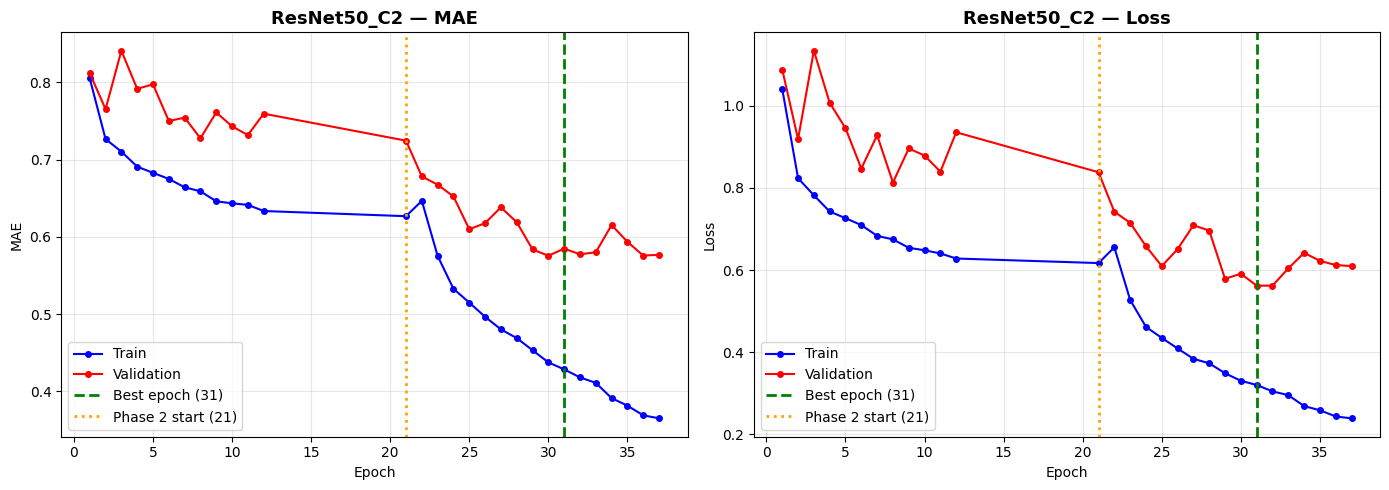

Total epochs: 29 (Phase 1: 12, Phase 2: 17)
Best epoch: 31
Early stopping at epoch: 37


In [7]:
# ── Training History Visualization — ResNet50_C2 (MAE + Loss) ────────────────
import json
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path.cwd().resolve()
report_dir = output_dir / 'reports'
MODEL_NAME = "ResNet50_C2"

with open(report_dir / 'train_history.json', 'r', encoding='utf-8') as f:
    history = json.load(f)

phase1_len = 12
phase2_start_keras = 20

epoch_labels = list(range(1, phase1_len + 1)) + list(range(phase2_start_keras + 1, phase2_start_keras + 1 + (len(history['loss']) - phase1_len)))

best_epoch = 31

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MAE
ax1.plot(epoch_labels, history['mae'], 'b-o', markersize=4, label='Train')
ax1.plot(epoch_labels, history['val_mae'], 'r-o', markersize=4, label='Validation')
ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax1.axvline(x=phase2_start_keras + 1, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start_keras + 1})')
ax1.set_title(f'{MODEL_NAME} — MAE', fontsize=13, fontweight='bold')
ax1.set_ylabel('MAE')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epoch_labels, history['loss'], 'b-o', markersize=4, label='Train')
ax2.plot(epoch_labels, history['val_loss'], 'r-o', markersize=4, label='Validation')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax2.axvline(x=phase2_start_keras + 1, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start_keras + 1})')
ax2.set_title(f'{MODEL_NAME} — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total epochs: {len(history["loss"])} (Phase 1: {phase1_len}, Phase 2: {len(history["loss"]) - phase1_len})')
print(f'Best epoch: {best_epoch}')

print(f'Early stopping at epoch: {epoch_labels[-1]}')




## 9. Validation Evaluation

### Performance on Validation Set
Evaluating the model's performance on the held-out validation set using loss and accuracy metrics.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# RESNET50_C2 — FULL STANDALONE EVALUATION (Validation + Test)
# Uses standard rounding to match comprehensive_metrics_matrix.csv
# ══════════════════════════════════════════════════════════════════════════════
import sys
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             mean_absolute_error, cohen_kappa_score,
                             roc_auc_score, precision_recall_fscore_support,
                             roc_curve, auc, confusion_matrix)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "ResNet50_C2"
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 16

output_dir = Path.cwd().resolve()
model_dir = output_dir / 'models'
report_dir = output_dir / 'reports'
best_model_path = model_dir / 'best_model.keras'

# ── Dataset paths ────────────────────────────────────────────────────────────
def find_dataset_dir():
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        for suffix in [('data', 'knee_osteoarthritis'), ('ml_workflow', 'data', 'knee_osteoarthritis'), ('Final_year_project', 'ml_workflow', 'data', 'knee_osteoarthritis')]:
            candidate = root.joinpath(*suffix)
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')

BASE_DIR = find_dataset_dir()
VALID_PATH = BASE_DIR / 'val'
TEST_PATH = BASE_DIR / 'test'

# ── Data generators ──────────────────────────────────────────────────────────
datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)
valid_generator = datagen.flow_from_directory(VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)

# ── Custom metrics (needed to load the model) ────────────────────────────────
@tf.keras.utils.register_keras_serializable(package='koa')
class OrdinalAccuracy(tf.keras.metrics.Metric):
    def __init__(self, num_classes=5, name='ordinal_accuracy', **kwargs):
        super(OrdinalAccuracy, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.counter = self.add_weight(name='counter', initializer='zeros', dtype=tf.float32)
        self.total = self.add_weight(name='total', initializer='zeros', dtype=tf.float32)
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(tf.round(tf.clip_by_value(tf.reshape(y_pred, [-1]), 0, self.num_classes - 1)), tf.int32)
        self.counter.assign_add(tf.cast(tf.reduce_sum(tf.cast(tf.equal(y_true, y_pred), tf.float32)), tf.float32))
        self.total.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))
    def result(self):
        return self.counter / (self.total + tf.keras.backend.epsilon())
    def reset_state(self):
        self.counter.assign(0.0)
        self.total.assign(0.0)
    def get_config(self):
        config = super().get_config()
        config.update({'num_classes': self.num_classes})
        return config

@tf.keras.utils.register_keras_serializable(package='Custom')
def ordinal_accuracy(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(tf.reshape(y_pred, [-1]), 0.0, 4.0)), tf.int32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32))

# ── Standard rounding (matches the original CSV) ─────────────────────────────
def standard_rounding(preds, n_classes=5):
    pred_values = np.asarray(preds, dtype=np.float32).reshape(-1)
    pred_values = np.clip(pred_values, 0, n_classes - 1)
    pred_labels = np.rint(pred_values).astype(int)
    return pred_values, pred_labels

# ── Ordinal score matrix for ROC curves ──────────────────────────────────────
def ordinal_score_matrix(predictions, n_classes=5):
    pred_values = np.asarray(predictions).reshape(-1)
    pred_values = np.clip(pred_values, 0, n_classes - 1)
    class_positions = np.arange(n_classes, dtype=np.float32)
    scores = 1.0 / (1.0 + np.abs(pred_values[:, None] - class_positions[None, :]))
    scores = scores / np.sum(scores, axis=1, keepdims=True)
    return scores

# ── Display function ─────────────────────────────────────────────────────────
def display_metrics(y_true, pred_labels, score_matrix, split_name, model_name):
    sep = '=' * 72
    sep2 = '-' * 72

    accuracy = accuracy_score(y_true, pred_labels)
    bal_accuracy = balanced_accuracy_score(y_true, pred_labels)
    mae = mean_absolute_error(y_true, pred_labels)
    qwk = cohen_kappa_score(y_true, pred_labels, weights='quadratic')

    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    try:
        macro_auc = roc_auc_score(y_true_bin, score_matrix, multi_class='ovr', average='macro')
    except:
        macro_auc = float('nan')

    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<44} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<44} {accuracy:>10.4f}')
    print(f'  {"Balanced Accuracy":<44} {bal_accuracy:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<44} {mae:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<44} {macro_auc:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<44} {qwk:>10.4f}')
    print(f'{sep}')

    prec, rec, f1, sup = precision_recall_fscore_support(y_true, pred_labels, labels=range(NUM_CLASSES), zero_division=0)
    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    for i, cname in enumerate(CLASS_NAMES):
        print(f'  {cname:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {int(sup[i]):>10}')
    print(f'  {sep2}')
    total_support = int(np.sum(sup))
    print(f'  {"accuracy":<14} {"":>10} {"":>10} {accuracy:>10.4f} {total_support:>10}')
    print(f'  {"macro avg":<14} {np.mean(prec):>10.4f} {np.mean(rec):>10.4f} {np.mean(f1):>10.4f} {total_support:>10}')
    print(f'  {"weighted avg":<14} {np.average(prec, weights=sup):>10.4f} {np.average(rec, weights=sup):>10.4f} {np.average(f1, weights=sup):>10.4f} {total_support:>10}')
    print(f'  {sep2}\n')

# ── Plot functions ───────────────────────────────────────────────────────────
def plot_roc(y_true, score_matrix, class_names, title):
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    plt.figure(figsize=(10, 7))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], score_matrix[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

def plot_f1(y_true, pred_labels, class_names, title):
    _, _, f1, _ = precision_recall_fscore_support(y_true, pred_labels, labels=range(len(class_names)), zero_division=0)
    plt.figure(figsize=(8, 5))
    bars = plt.bar(class_names, f1, color='steelblue', edgecolor='black')
    for bar, val in zip(bars, f1):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=10)
    plt.ylim(0, 1.0)
    plt.ylabel('F1 Score')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_cm(y_true, pred_labels, class_names, title, normalize=False):
    cm = confusion_matrix(y_true, pred_labels, labels=range(len(class_names)))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(7, 6))
    fmt = '.2f' if normalize else 'd'
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# ── Load model ───────────────────────────────────────────────────────────────
best_model = tf.keras.models.load_model(str(best_model_path), safe_mode=False)
print('Loaded best model from:', best_model_path)


I0000 00:00:1783478192.539034    1757 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5050, compute capability 12.0


W0000 00:00:1783478235.282156    1757 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1783478235.412684    1757 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1783478235.732903    1757 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5263 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


Loaded best model from: /workspaces/fyp_experiment/Final_year_project/ml_workflow/training/knee_osteoarthritis/ResNet_50/ResNet_50_C2/models/best_model.keras


I0000 00:00:1783478792.922010    1757 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783478806.726812   16803 cuda_dnn.cc:461] Loaded cuDNN version 90701


52/52 [==============================] - 31s 154ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : ResNet50_C2
  Split : Validation
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5315
  Balanced Accuracy                                0.5830
  Mean Absolute Error (MAE)                        0.5278
  Macro ROC AUC (ordinal matrix)                   0.8423
  Quadratic Weighted Kappa (QWK)                   0.7496

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.7347     0.5488     0.6283        328
  Doubtful           0.2577     0.4902     0.3378        153
  Minimal            0.5531     0.4670     0.5064        212
  Moderate        

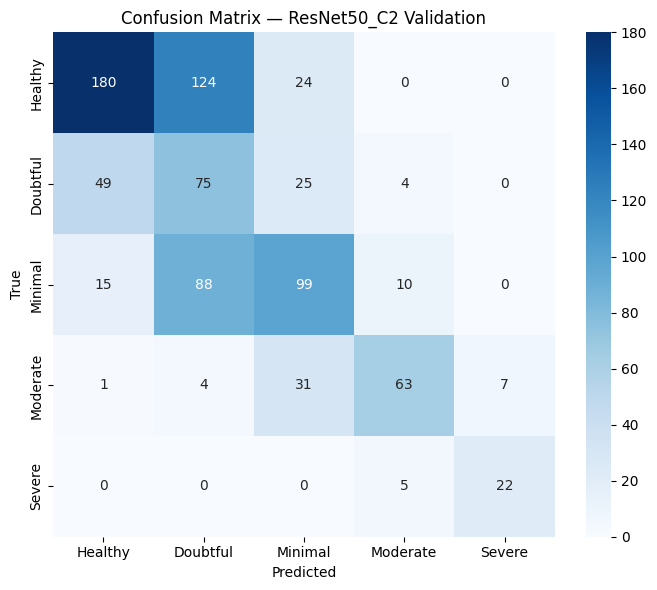

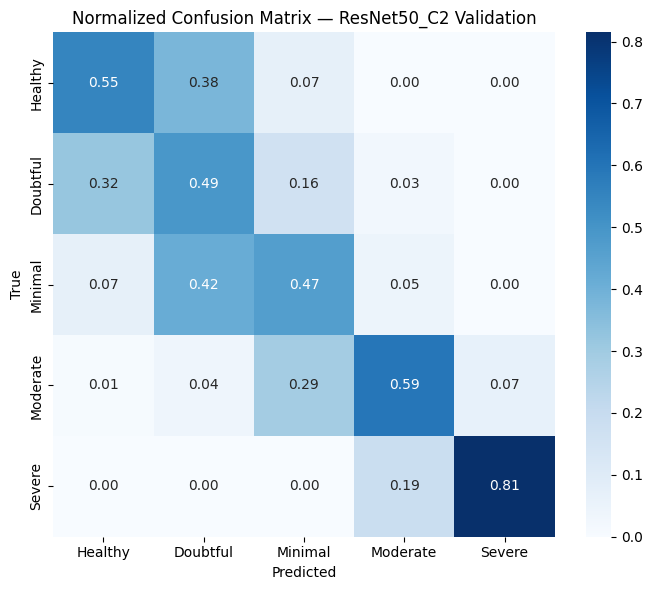

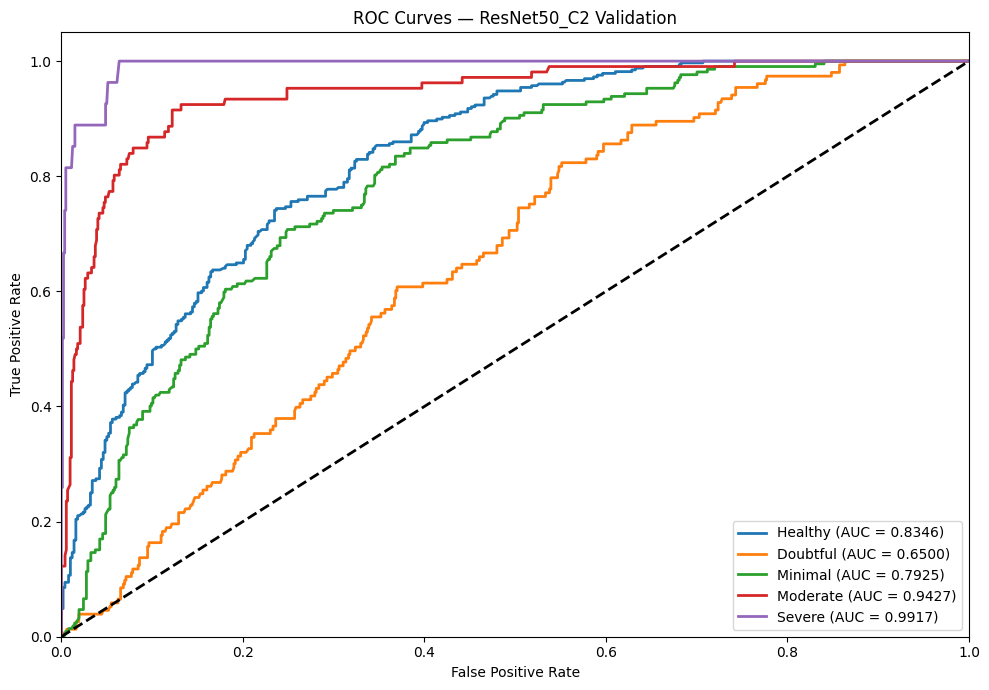

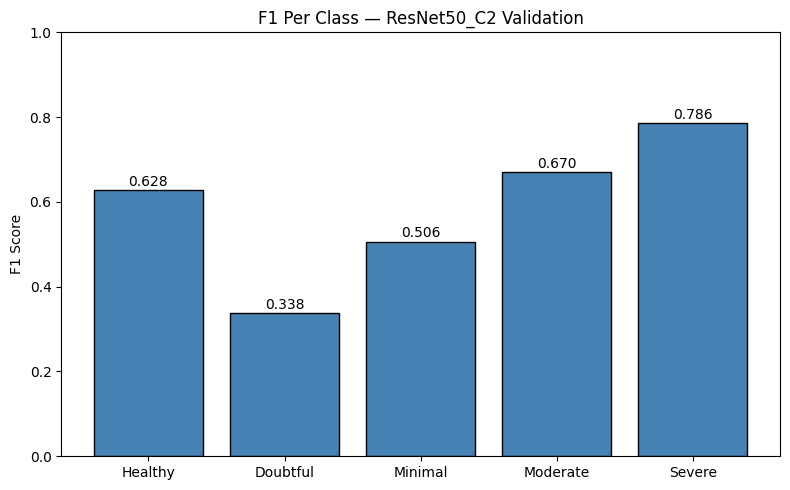

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION
# ══════════════════════════════════════════════════════════════════════════════
valid_generator.reset()
val_continuous = best_model.predict(valid_generator, verbose=1).reshape(-1)
val_true = valid_generator.labels

_, val_pred_labels = standard_rounding(val_continuous)
val_scores = ordinal_score_matrix(val_continuous)

display_metrics(val_true, val_pred_labels, val_scores, 'Validation', MODEL_NAME)
plot_cm(val_true, val_pred_labels, CLASS_NAMES, f'Confusion Matrix — {MODEL_NAME} Validation', normalize=False)
plot_cm(val_true, val_pred_labels, CLASS_NAMES, f'Normalized Confusion Matrix — {MODEL_NAME} Validation', normalize=True)
plot_roc(val_true, val_scores, CLASS_NAMES, f'ROC Curves — {MODEL_NAME} Validation')
plot_f1(val_true, val_pred_labels, CLASS_NAMES, f'F1 Per Class — {MODEL_NAME} Validation')


## 10. Test Set Evaluation

Reload the best saved model and run the final evaluation on the independent test split.

104/104 [==============================] - 13s 127ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : ResNet50_C2
  Split : Test
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5707
  Balanced Accuracy                                0.6075
  Mean Absolute Error (MAE)                        0.4795
  Macro ROC AUC (ordinal matrix)                   0.8593
  Quadratic Weighted Kappa (QWK)                   0.7763

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.7470     0.5775     0.6514        639
  Doubtful           0.2808     0.5236     0.3656        296
  Minimal            0.6342     0.5391     0.5828        447
  Moderate           0

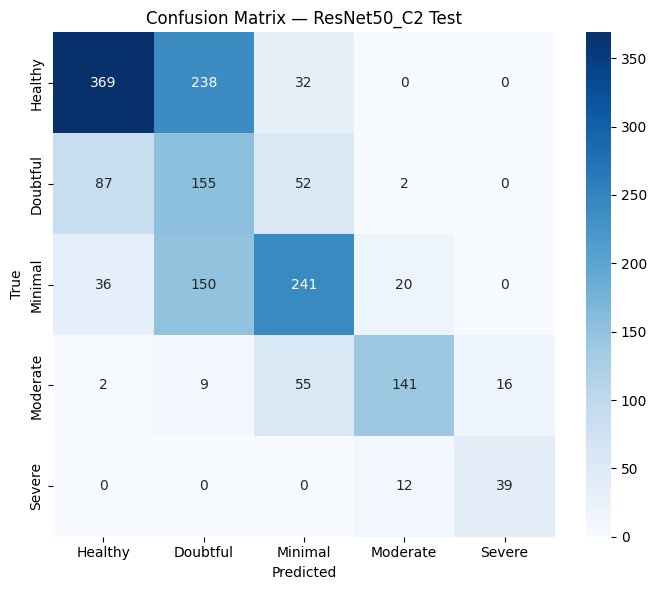

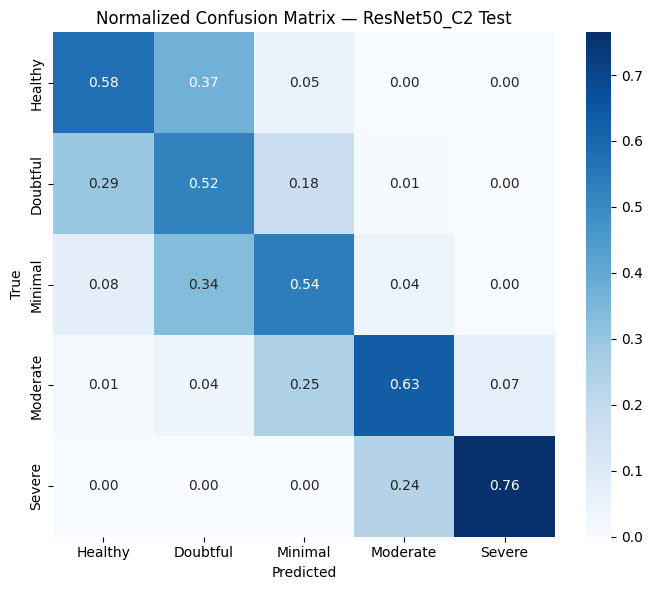

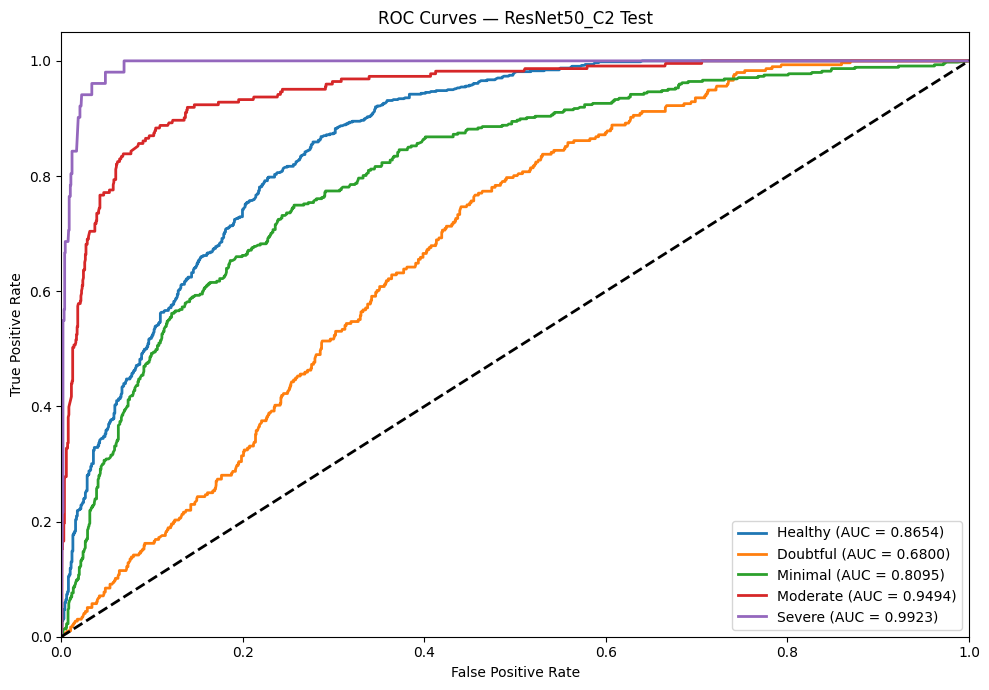

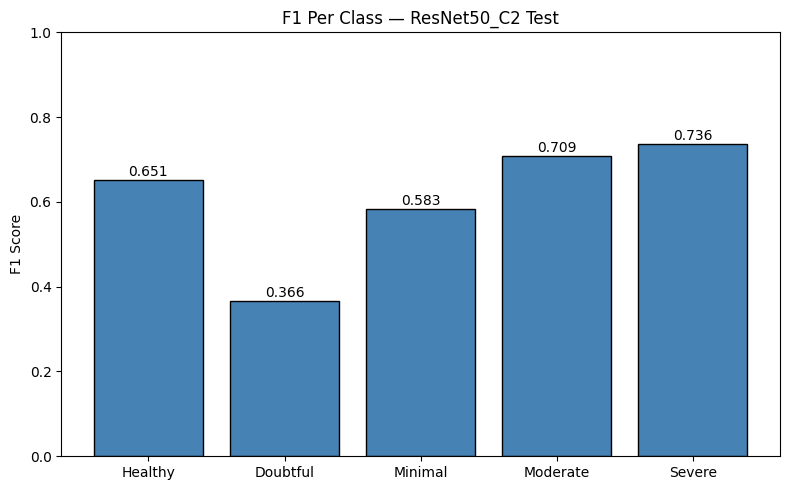

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# TEST
# ══════════════════════════════════════════════════════════════════════════════
test_generator.reset()
test_continuous = best_model.predict(test_generator, verbose=1).reshape(-1)
test_true = test_generator.labels

_, test_pred_labels = standard_rounding(test_continuous)
test_scores = ordinal_score_matrix(test_continuous)

display_metrics(test_true, test_pred_labels, test_scores, 'Test', MODEL_NAME)
plot_cm(test_true, test_pred_labels, CLASS_NAMES, f'Confusion Matrix — {MODEL_NAME} Test', normalize=False)
plot_cm(test_true, test_pred_labels, CLASS_NAMES, f'Normalized Confusion Matrix — {MODEL_NAME} Test', normalize=True)
plot_roc(test_true, test_scores, CLASS_NAMES, f'ROC Curves — {MODEL_NAME} Test')
plot_f1(test_true, test_pred_labels, CLASS_NAMES, f'F1 Per Class — {MODEL_NAME} Test')


## 12. Model Interpretability & Visualization

Grad-CAM helps verify whether the model focuses on clinically relevant regions instead of irrelevant background patterns.

In [21]:
def make_gradcam_heatmap(grad_model, img_array, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * alpha + img
    return tf.keras.preprocessing.image.array_to_img(superimposed_img)

----test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%
Test data - Healthy


/tmp/ipykernel_8201/809071120.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap('jet')


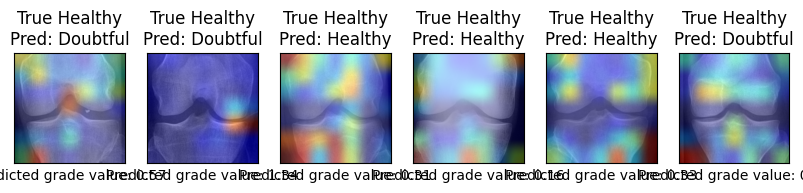

Test data - Doubtful


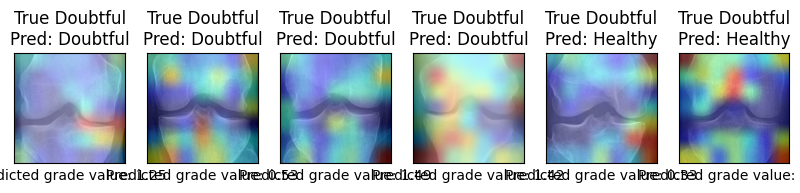

Test data - Minimal


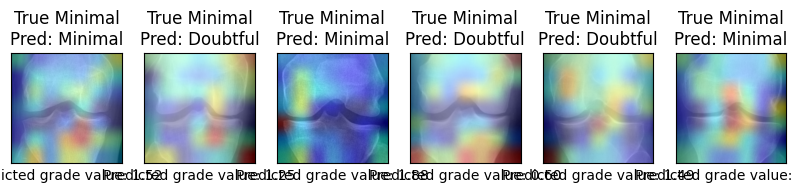

Test data - Moderate


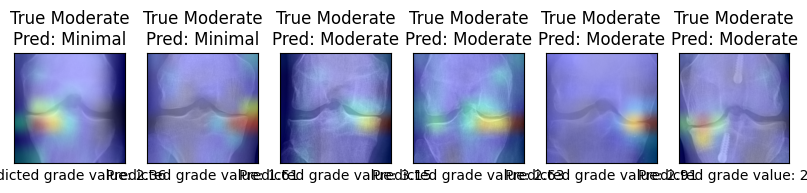

Test data - Severe


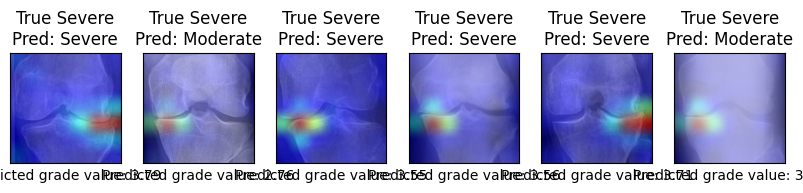

In [22]:
tests_data = get_classes(TEST_PATH, CLASS_NAMES, 'test')
resnet_backbone = resnet_model.get_layer('resnet50')
last_conv_layer = resnet_backbone.get_layer('conv5_block3_out')

gap_layer = next(layer for layer in resnet_model.layers if isinstance(layer, layers.GlobalAveragePooling2D))
dense_layers = [layer for layer in resnet_model.layers if isinstance(layer, layers.Dense)]
dropout_layer = next(layer for layer in resnet_model.layers if isinstance(layer, layers.Dropout))

x = gap_layer(resnet_backbone.output)
x = dense_layers[0](x)
x = dropout_layer(x)
predictions = dense_layers[-1](x)

# Rebuild the Grad-CAM graph from the backbone input so tensor connections stay valid.
grad_model = tf.keras.models.Model(
    inputs=resnet_backbone.input,
    outputs=[last_conv_layer.output, predictions],
)
gradcam_dir = 'gradcam_outputs'
os.makedirs(gradcam_dir, exist_ok=True)

for k, v in tests_data.items():
    print(f'Test data - {CLASS_NAMES[k]}')
    plt.figure(figsize=(10, 28))
    for i in range(6):
        img_path = os.path.join(TEST_PATH, str(k), v[i])
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img.copy(), axis=0)
        img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
        y_pred = resnet_model.predict(img_array, verbose=0)[0]
        heatmap = make_gradcam_heatmap(grad_model, img_array)
        image = save_and_display_gradcam(img, heatmap)
        image.save(os.path.join(gradcam_dir, f'{CLASS_NAMES[k]}_{i + 1}.png'))
        plt.subplot(1, 6, i + 1, xticks=[], yticks=[])
        plt.imshow(image)
        _, gradcam_pred_label = ordinal_predictions_to_labels(y_pred, CLASS_NAMES)
        plt.title(f'True {CLASS_NAMES[k]}\nPred: {CLASS_NAMES[gradcam_pred_label[0]]}')
        plt.xlabel(f'Predicted grade value: {float(np.asarray(y_pred).reshape(-1)[0]):.2f}')
    plt.show()